#  SkinSight AI — 04 · Évaluation du modèle

Analyse complète des performances du modèle LightGBM final :
matrice de confusion, métriques par classe, analyse des erreurs.

In [1]:
import os, joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR  = os.path.join(BASE_DIR, 'data')
CLASSES   = ['saine', 'acne_inflammatoire', 'acne_non_inflammatoire', 'rosacee', 'hyperpigmentation']
CLASSES_FR = ['Peau saine', 'Acné inflam.', 'Acné non-inflam.', 'Rosacée', 'Hyperpigm.']
COLORS    = ['#C07A5A', '#8B6A8B', '#D4A896', '#7A9E7E', '#B8956A']

print('Prêt')

Prêt


## 1. Chargement modèle et données

In [15]:
lgbm   = joblib.load(os.path.join(MODEL_DIR, 'lightgbm.pkl'))
X_test = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

y_pred  = lgbm.predict(X_test)
y_proba = lgbm.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred) * 100
f1  = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy : {acc:.2f}%')
print(f'F1 weighted : {f1:.4f}')

Accuracy : 86.29%
F1 weighted : 0.8622


## 2. Rapport de classification

In [21]:
print(classification_report(y_test, y_pred, target_names=CLASSES_FR, digits=3))

                  precision    recall  f1-score   support

      Peau saine      1.000     1.000     1.000       150
    Acné inflam.      0.830     0.868     0.848       174
Acné non-inflam.      0.758     0.708     0.732       106
         Rosacée      0.788     0.893     0.838        75
      Hyperpigm.      0.893     0.779     0.832        86

        accuracy                          0.863       591
       macro avg      0.854     0.850     0.850       591
    weighted avg      0.864     0.863     0.862       591



## 3. Matrice de confusion

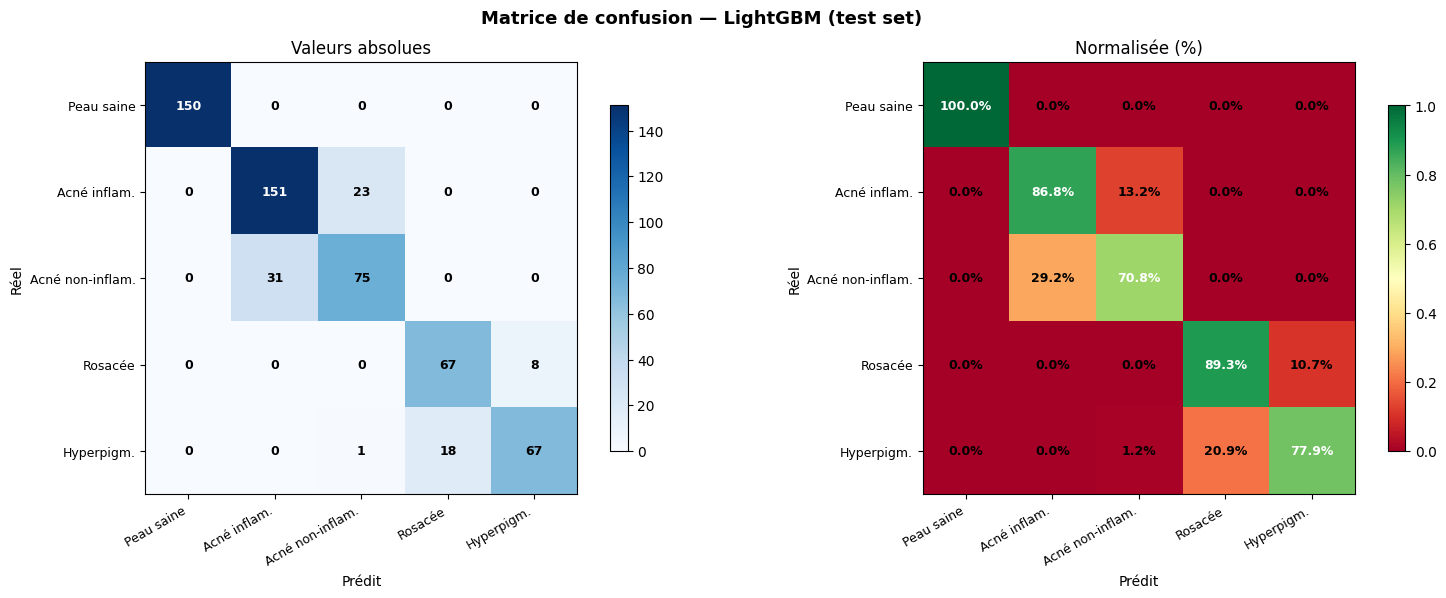

In [26]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrice de confusion — LightGBM (test set)', fontsize=13, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], cm,      'Valeurs absolues', 'd'),
    (axes[1], cm_norm, 'Normalisée (%)',   '.1%')
]:
    cmap = plt.cm.RdYlGn if fmt == '.1%' else plt.cm.Blues
    im = ax.imshow(data, cmap=cmap, vmin=0, vmax=(1 if fmt=='.1%' else None))
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(CLASSES_FR))); ax.set_xticklabels(CLASSES_FR, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(CLASSES_FR))); ax.set_yticklabels(CLASSES_FR, fontsize=9)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
    ax.set_title(title)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            val = data[i, j]
            txt = format(val, fmt)
            color = 'white' if (fmt=='.1%' and val > 0.6) or (fmt=='d' and val > cm.max()*0.6) else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_04_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. F1-score par classe

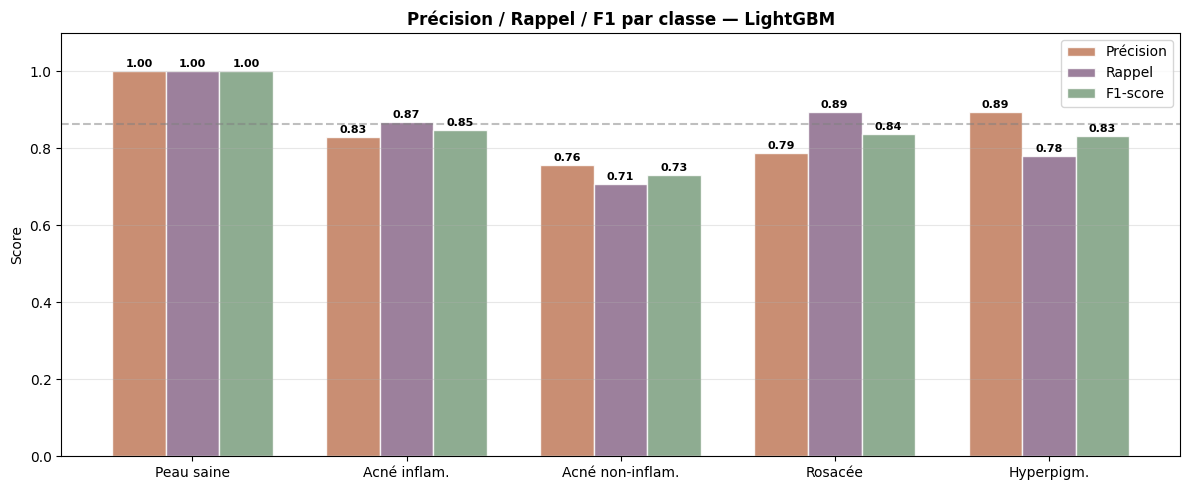

In [30]:
f1_per_class = f1_score(y_test, y_pred, average=None)
prec_per_class = __import__('sklearn.metrics', fromlist=['precision_score']).precision_score(y_test, y_pred, average=None)
rec_per_class  = __import__('sklearn.metrics', fromlist=['recall_score']).recall_score(y_test,  y_pred, average=None)

x = np.arange(len(CLASSES))
fig, ax = plt.subplots(figsize=(12, 5))
w = 0.25
for i, (vals, label, color) in enumerate([
    (prec_per_class, 'Précision', '#C07A5A'),
    (rec_per_class,  'Rappel',    '#8B6A8B'),
    (f1_per_class,   'F1-score',  '#7A9E7E'),
]):
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES_FR, fontsize=10)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1)
ax.set_title('Précision / Rappel / F1 par classe — LightGBM', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.axhline(f1.mean() if hasattr(f1,'mean') else f1, color='gray', linestyle='--', alpha=0.5, label='F1 moyen')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_04_f1_par_classe.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Courbes ROC (One-vs-Rest)

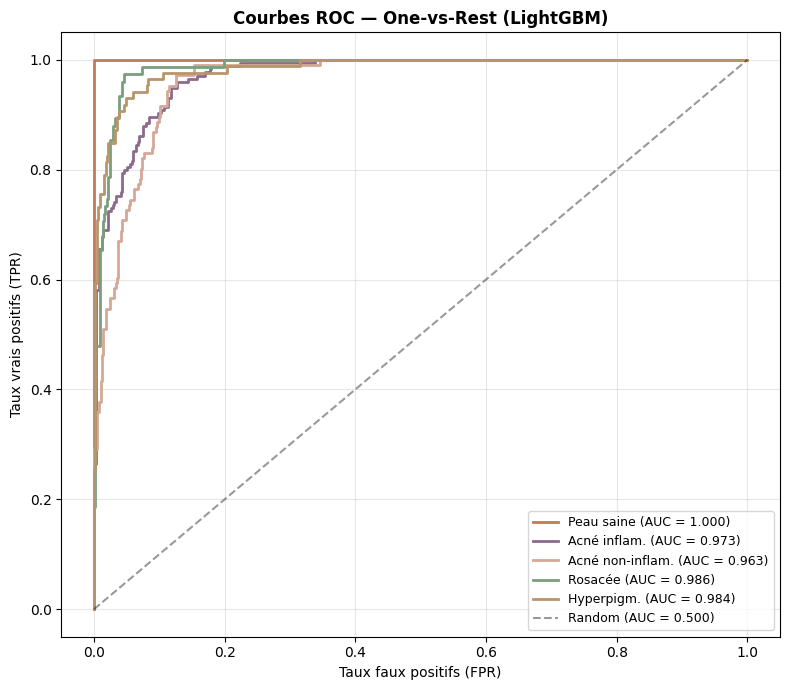

In [33]:
y_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(8, 7))
for i, (cls_fr, color) in enumerate(zip(CLASSES_FR, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls_fr} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')
ax.set_xlabel('Taux faux positifs (FPR)')
ax.set_ylabel('Taux vrais positifs (TPR)')
ax.set_title('Courbes ROC — One-vs-Rest (LightGBM)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_04_roc.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Analyse des erreurs typiques

In [35]:
# Confusions les plus fréquentes
errors = []
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if i != j and cm[i, j] > 0:
            errors.append({
                'reel':   CLASSES_FR[i],
                'predit': CLASSES_FR[j],
                'count':  cm[i, j],
                'pct':    cm_norm[i, j] * 100
            })

errors.sort(key=lambda x: x['count'], reverse=True)

print(f'Top confusions :\n')
print(f'  {"Réel":<22} → {"Prédit":<22}  {"N":>5}  {"(%)"}' )
print('  ' + '-' * 60)
for e in errors[:8]:
    print(f'  {e["reel"]:<22} → {e["predit"]:<22}  {e["count"]:>5}  ({e["pct"]:.1f}%)')

Top confusions :

  Réel                   → Prédit                      N  (%)
  ------------------------------------------------------------
  Acné non-inflam.       → Acné inflam.               31  (29.2%)
  Acné inflam.           → Acné non-inflam.           23  (13.2%)
  Hyperpigm.             → Rosacée                    18  (20.9%)
  Rosacée                → Hyperpigm.                  8  (10.7%)
  Hyperpigm.             → Acné non-inflam.            1  (1.2%)


## Résumé des performances

| Métrique | Valeur |
|----------|--------|
| Accuracy (test) | **86.29%** |
| F1-score weighted | **0.862** |
| Meilleure classe | Peau saine |
| Classe la plus difficile | Acné non-inflammatoire / Rosacée |

> **Analyse des erreurs :** Les confusions les plus fréquentes sont entre
> `acne_non_inflammatoire` et `rosacee` — deux pathologies visuellement proches
> (rougeurs diffuses, absence de pustules). Une amélioration possible serait
> d'ajouter un modèle de segmentation pour isoler les zones affectées.